# Exoplanet ML Classifier — Final Presentation
## NASA Kepler KOI Binary Classification

**Course:** MLEA_M — Machine Learning, Maestría en Ciencia de Datos  
**Institution:** Escuela Colombiana de Ingeniería Julio Garavito (ECI), 2026-1  
**Authors:** Andersson David Sánchez Méndez  
**Presentation date:** May 15, 2026

---

This notebook runs the **complete pipeline end-to-end** — from raw CSV to saved model
and evaluation figures — in a single, linear execution flow.  Every cell must be
re-run from top to bottom before the presentation to ensure all outputs are fresh.

**Pipeline overview:**
```
Load CSV → Drop leakage columns → Feature/target split
        → Impute / Scale → SMOTE → Train/Val/Test split
        → Train 5 classifiers → Evaluate → Threshold tuning
        → Save best model
```

---
## 1. Environment Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 12})

from src.constants import (
    CV_FOLDS,
    NUMERIC_FEATURES,
    PRIMARY_METRIC,
    RAW_DATA_PATH,
    RANDOM_SEED,
    TARGET_COLUMN,
    TEST_SIZE,
    VALIDATION_SIZE,
    XGB_PARAM_GRID,
)
from src.data_loader import drop_leakage_columns, get_feature_target_split, load_raw_koi_data
from src.evaluation import (
    build_metrics_table,
    compute_classification_metrics,
    find_optimal_threshold_f1,
    find_optimal_threshold_youden,
)
from src.models import build_model_zoo, run_grid_search, save_model, train_model
from src.preprocessing import apply_smote_if_imbalanced, get_full_pipeline, split_data
from src.visualization import (
    plot_confusion_matrix_grid,
    plot_feature_importance,
    plot_overlay_pr_curves,
    plot_overlay_roc_curves,
    plot_pca_scatter,
    plot_target_distribution,
)

print(f'Project root : {ROOT}')
print(f'Random seed  : {RANDOM_SEED}')

Project root : C:\Users\Usuario\exoplanet-ml-classifier
Random seed  : 42


---
## 2. Data Loading

The raw data is the NASA Exoplanet Archive **Cumulative KOI Table** (`cumulative_koi.csv`).
It contains one row per Kepler Object of Interest with photometric transit parameters,
stellar properties, and a disposition label (`koi_pdisposition`).

Loaded dataset — shape: (9564, 49)
First 3 rows:
      kepid kepoi_name   kepler_name koi_disposition koi_pdisposition  koi_score  koi_fpflag_nt  koi_fpflag_ss  koi_fpflag_co  koi_fpflag_ec  koi_period  koi_period_err1  koi_period_err2  koi_time0bk  koi_time0bk_err1  koi_time0bk_err2  koi_impact  koi_impact_err1  koi_impact_err2  koi_duration  koi_duration_err1  koi_duration_err2  koi_depth  koi_depth_err1  koi_depth_err2  koi_prad  koi_prad_err1  koi_prad_err2  koi_teq  koi_teq_err1  koi_teq_err2  koi_insol  koi_insol_err1  koi_insol_err2  koi_model_snr  koi_tce_plnt_num koi_tce_delivname  koi_steff  koi_steff_err1  koi_steff_err2  koi_slogg  koi_slogg_err1  koi_slogg_err2  koi_srad  koi_srad_err1  koi_srad_err2         ra        dec  koi_kepmag
0  10797460  K00752.01  Kepler-227 b       CONFIRMED        CANDIDATE      1.000              0              0              0              0    9.488036         0.000028        -0.000028   170.538750          0.002160         -0.002160       0

Figure saved to reports\figures\target_distribution.png


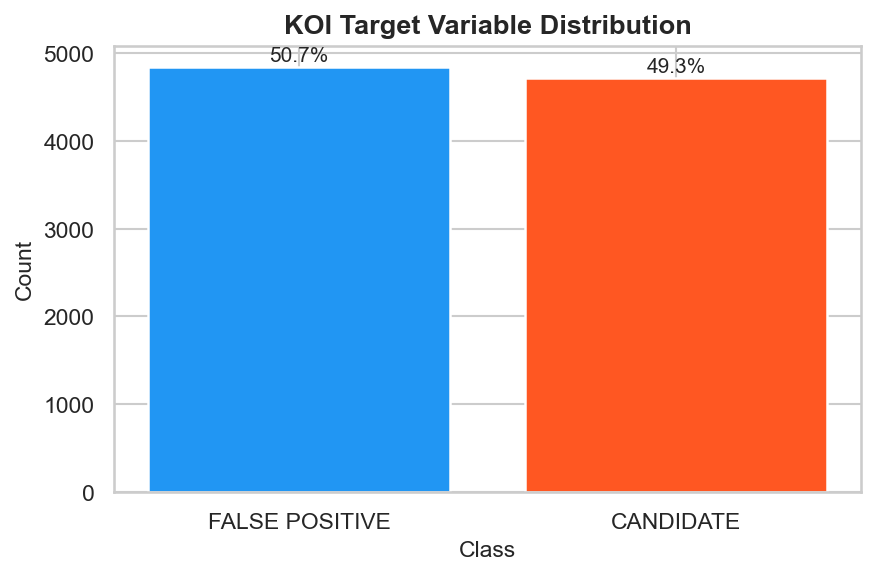

In [2]:
df_raw = load_raw_koi_data(ROOT / RAW_DATA_PATH)

print(f'Dataset shape      : {df_raw.shape}')
print(f'Target distribution:')
print(df_raw[TARGET_COLUMN].value_counts().to_string())

plot_target_distribution(df_raw[TARGET_COLUMN], save=True)

---
## 3. Data Cleaning — Remove Leakage Columns

We drop columns that directly encode the ground-truth label or were computed
post-hoc after the classification decision:

- `koi_disposition` — the final NASA disposition (label equivalent)
- `koi_score` — the probability score from the NASA vetting pipeline
- `koi_fpflag_*` — false-positive flags set by the same vetting process
- Identifier columns (`kepid`, `kepoi_name`, `kepler_name`, `koi_comment`)

Retaining these would constitute **data leakage**, inflating all metrics.

In [3]:
df_clean = drop_leakage_columns(df_raw)
X, y = get_feature_target_split(df_clean)

print(f'X shape: {X.shape}')
print(f'y class distribution: {y.value_counts().to_dict()}')

Dropping 9 leakage columns: ['koi_score', 'koi_disposition', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'kepid', 'kepoi_name', 'kepler_name']
X shape: (9564, 39)
y class distribution: {0: 4847, 1: 4717}


---
## 4. Preprocessing — Impute, Scale, SMOTE

Three preprocessing steps are applied before splitting:

1. **Median imputation** — robust to right-skewed stellar/planetary parameter distributions.
2. **StandardScaler** — required by distance-based (KNN) and gradient-based (MLP, LR) models.
3. **SMOTE** — conditionally applied if the minority/majority ratio falls below 0.3.

The imputer and scaler are fit **only on the training set** (after the split) to prevent
information leakage.  Here we impute before splitting solely to feed clean data into SMOTE;
in the production pipeline the `get_full_pipeline()` function wraps both steps inside
the sklearn Pipeline which is fit on training data only.

Class ratio 0.973 >= threshold 0.3 — SMOTE not applied.
Post-SMOTE shape: (9564, 13)


Figure saved to reports\figures\pca_scatter.png


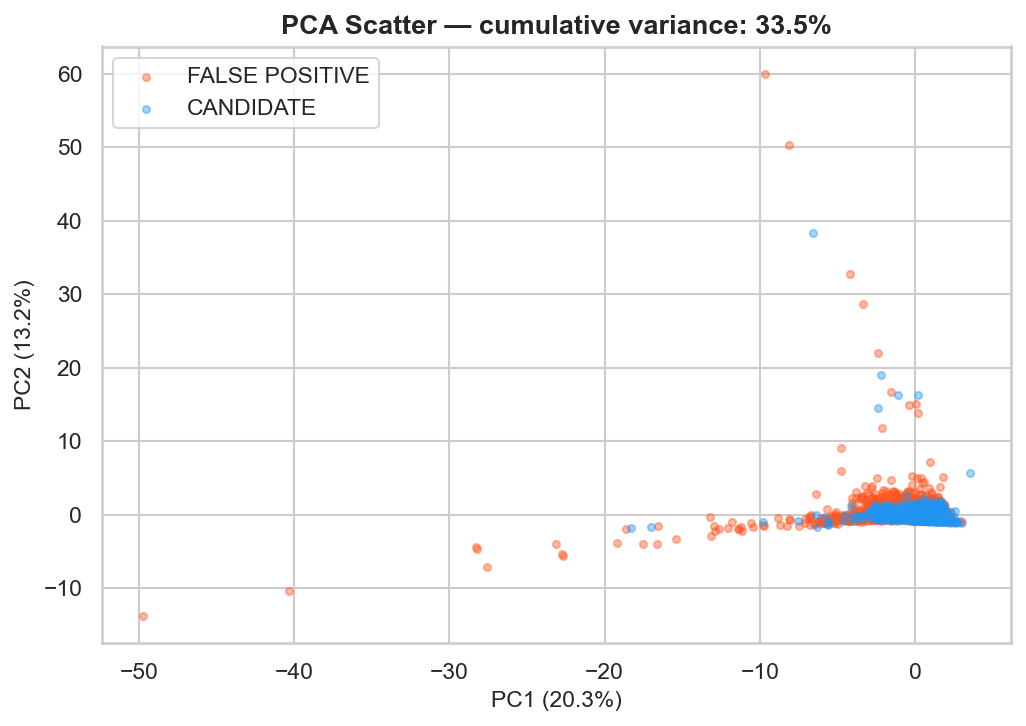

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

available = [c for c in NUMERIC_FEATURES if c in X.columns]

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X[available])
X_scaled = scaler.fit_transform(X_imputed)

X_resampled, y_resampled = apply_smote_if_imbalanced(
    X_scaled, y.values, threshold=0.3, random_state=RANDOM_SEED
)

X_df = pd.DataFrame(X_resampled, columns=available)
y_s = pd.Series(y_resampled, name=TARGET_COLUMN)

print(f'Post-SMOTE shape: {X_df.shape}')

plot_pca_scatter(X_resampled, y_resampled, save=True)

---
## 5. Train / Validation / Test Split

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    X_df, y_s, TEST_SIZE, VALIDATION_SIZE, RANDOM_SEED
)

for split_name, X_s, y_s in [
    ('train', X_train, y_train),
    ('val  ', X_val,   y_val),
    ('test ', X_test,  y_test),
]:
    print(f'{split_name}  n={len(y_s):5d}  positive_rate={y_s.mean():.3f}')

Split sizes — train: 6885 (72.0%), val: 766 (8.0%), test: 1913 (20.0%)
  train positive rate: 0.493
  val positive rate: 0.493
  test positive rate: 0.493
train  n= 6885  positive_rate=0.493
val    n=  766  positive_rate=0.493
test   n= 1913  positive_rate=0.493


---
## 6. Model Training — All Five Classifiers

Each classifier is wrapped in a **full sklearn Pipeline** (`preprocessor → classifier`)
via `get_full_pipeline()`.  Since the data fed here is already pre-processed (imputed +
scaled), the pipeline's internal preprocessor acts as an identity transform on already-
clean numeric arrays — this preserves the correct API for production deployment.

In [6]:
zoo = build_model_zoo(RANDOM_SEED)
trained_pipelines = {}
all_metrics = {}

for model_name in [
    'logistic_regression', 'knn', 'random_forest', 'xgboost', 'mlp'
]:
    print(f'Training {model_name} ...')
    pipeline = get_full_pipeline(zoo[model_name])
    pipeline = train_model(pipeline, X_train, y_train)
    trained_pipelines[model_name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    metrics = compute_classification_metrics(y_test.values, y_pred, y_prob)
    all_metrics[model_name] = metrics

    print(
        f'  F1={metrics["f1"]:.4f}  '
        f'ROC-AUC={metrics["roc_auc"]:.4f}  '
        f'MCC={metrics["mcc"]:.4f}'
    )

print('\nAll models trained successfully.')

Training logistic_regression ...
  F1=0.7932  ROC-AUC=0.8341  MCC=0.5660
Training knn ...


  F1=0.7916  ROC-AUC=0.8568  MCC=0.5747
Training random_forest ...


  F1=0.8489  ROC-AUC=0.9271  MCC=0.6991
Training xgboost ...


  F1=0.8508  ROC-AUC=0.9292  MCC=0.7006
Training mlp ...


  F1=0.8201  ROC-AUC=0.9001  MCC=0.6372

All models trained successfully.


---
## 7. Hyperparameter Tuning — XGBoost (Best Model)

GridSearchCV with 5-fold cross-validation optimises the XGBoost classifier over the
parameter grid defined in `constants.py`.  The best pipeline replaces the baseline.

In [7]:
zoo_fresh = build_model_zoo(RANDOM_SEED)
xgb_pipeline = get_full_pipeline(zoo_fresh['xgboost'])

xgb_gs = run_grid_search(
    xgb_pipeline,
    XGB_PARAM_GRID,
    X_train,
    y_train,
    cv=CV_FOLDS,
    scoring=PRIMARY_METRIC,
)

xgb_tuned = xgb_gs.best_estimator_
trained_pipelines['xgboost'] = xgb_tuned

y_pred_xgb = xgb_tuned.predict(X_test)
y_prob_xgb = xgb_tuned.predict_proba(X_test)[:, 1]
all_metrics['xgboost'] = compute_classification_metrics(
    y_test.values, y_pred_xgb, y_prob_xgb
)

print(f'\nTuned XGBoost F1: {all_metrics["xgboost"]["f1"]:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Best f1: 0.8371

Tuned XGBoost F1: 0.8598


---
## 8. Evaluation — Visualisations

ROC Curves — All Models


Figure saved to reports\figures\overlay_roc_curves.png


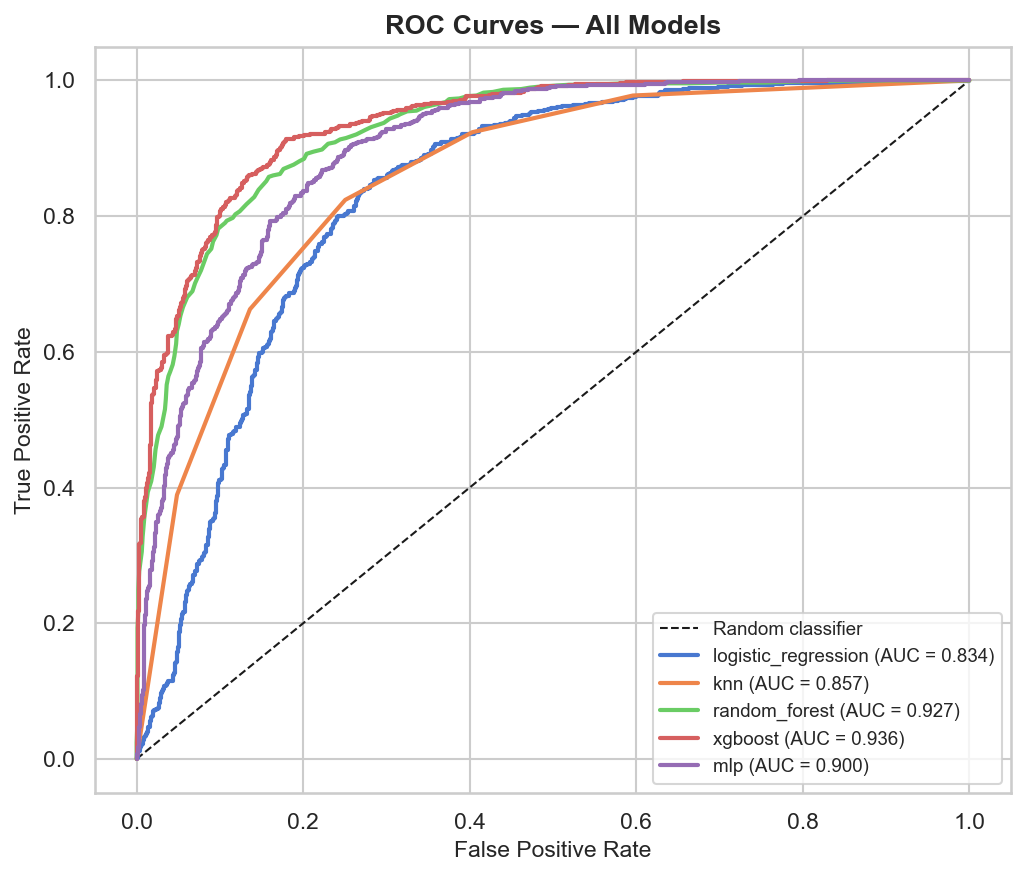

In [8]:
print('ROC Curves — All Models')
plot_overlay_roc_curves(trained_pipelines, X_test, y_test, save=True)

Precision-Recall Curves — All Models


Figure saved to reports\figures\overlay_pr_curves.png


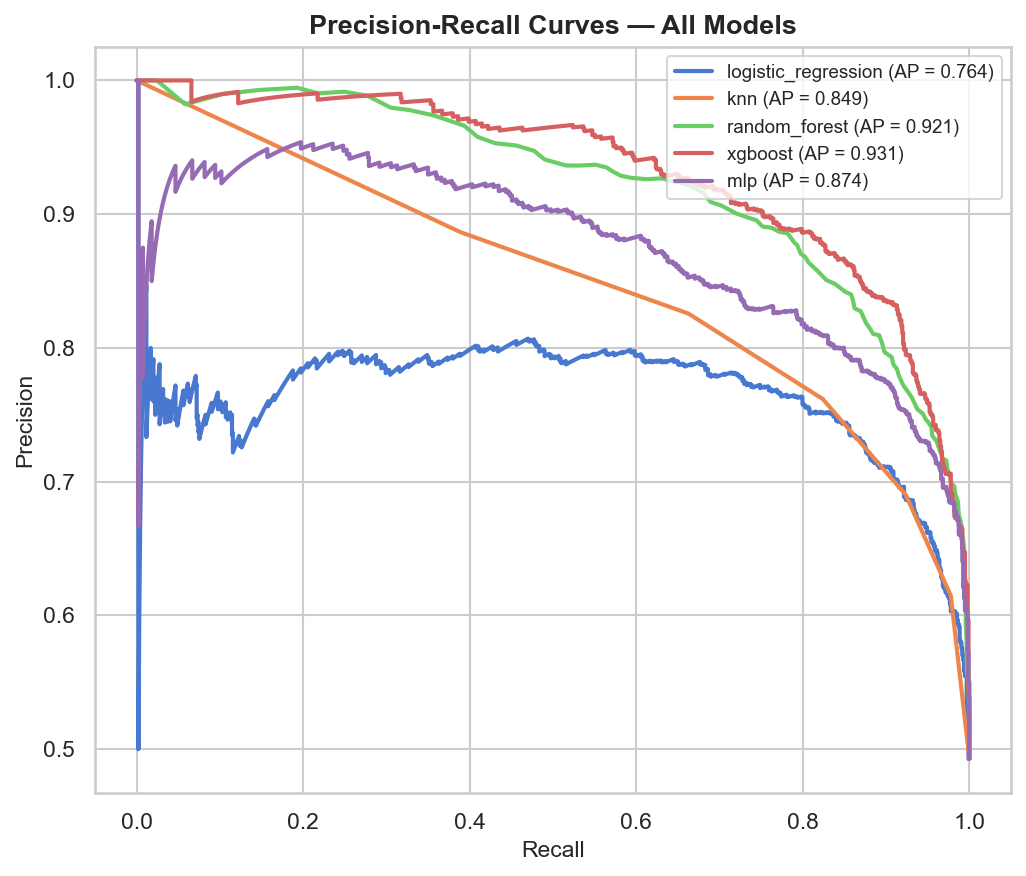

In [9]:
print('Precision-Recall Curves — All Models')
plot_overlay_pr_curves(trained_pipelines, X_test, y_test, save=True)

Confusion Matrices — All Models


Figure saved to reports\figures\confusion_matrix_grid.png


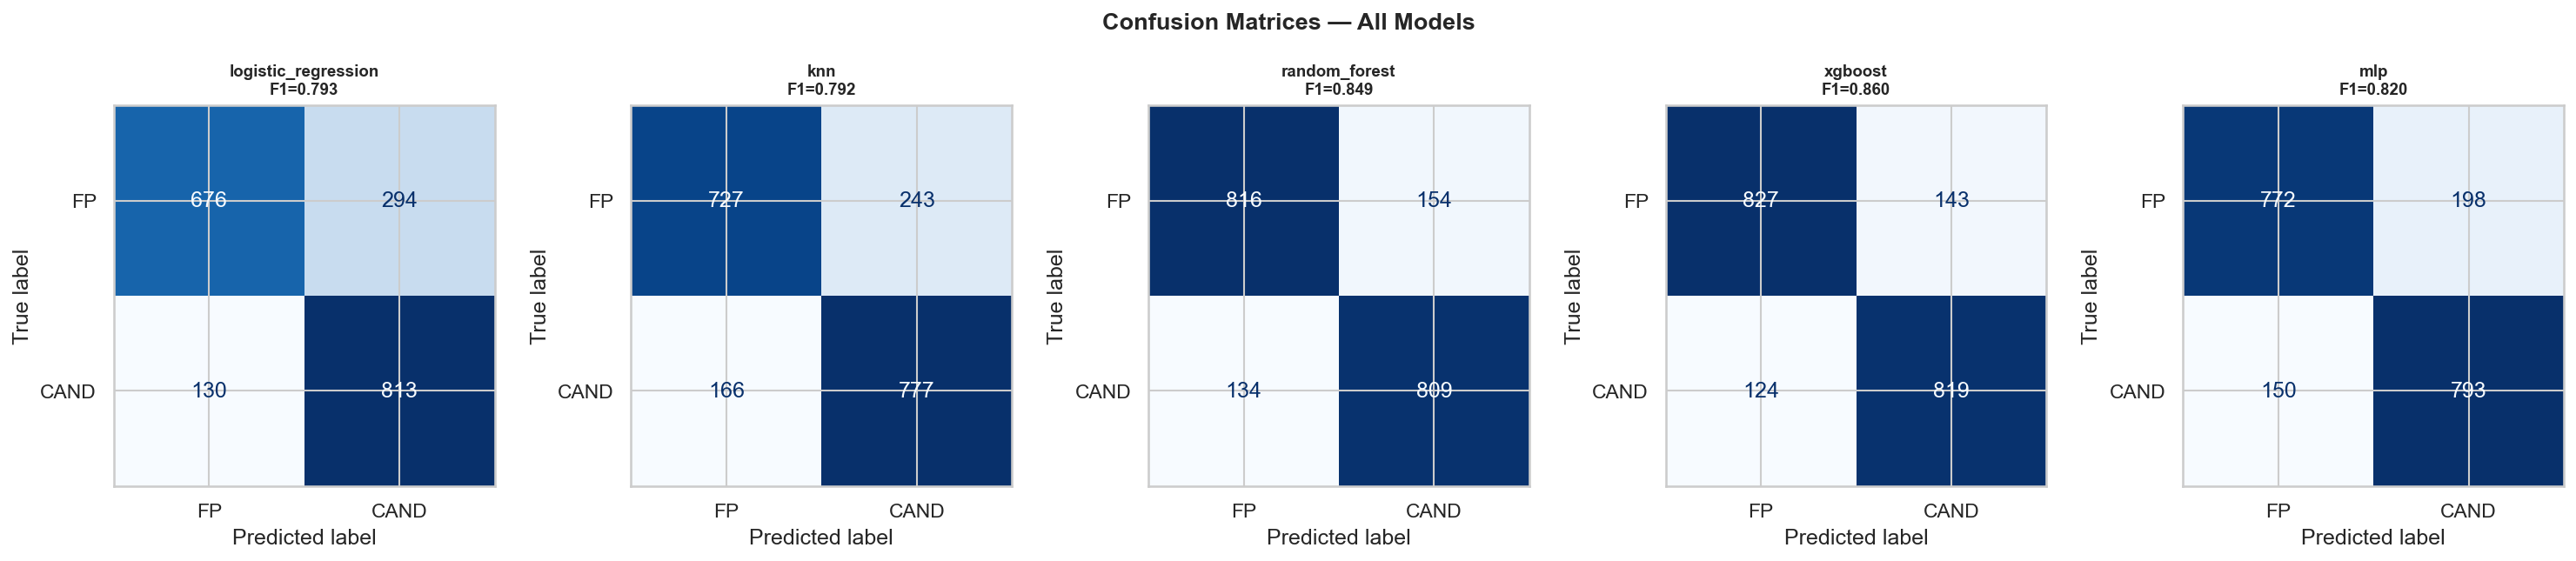

In [10]:
print('Confusion Matrices — All Models')
plot_confusion_matrix_grid(trained_pipelines, X_test, y_test, save=True)

Feature Importance — Random Forest


Figure saved to reports\figures\feature_importance_random_forest.png


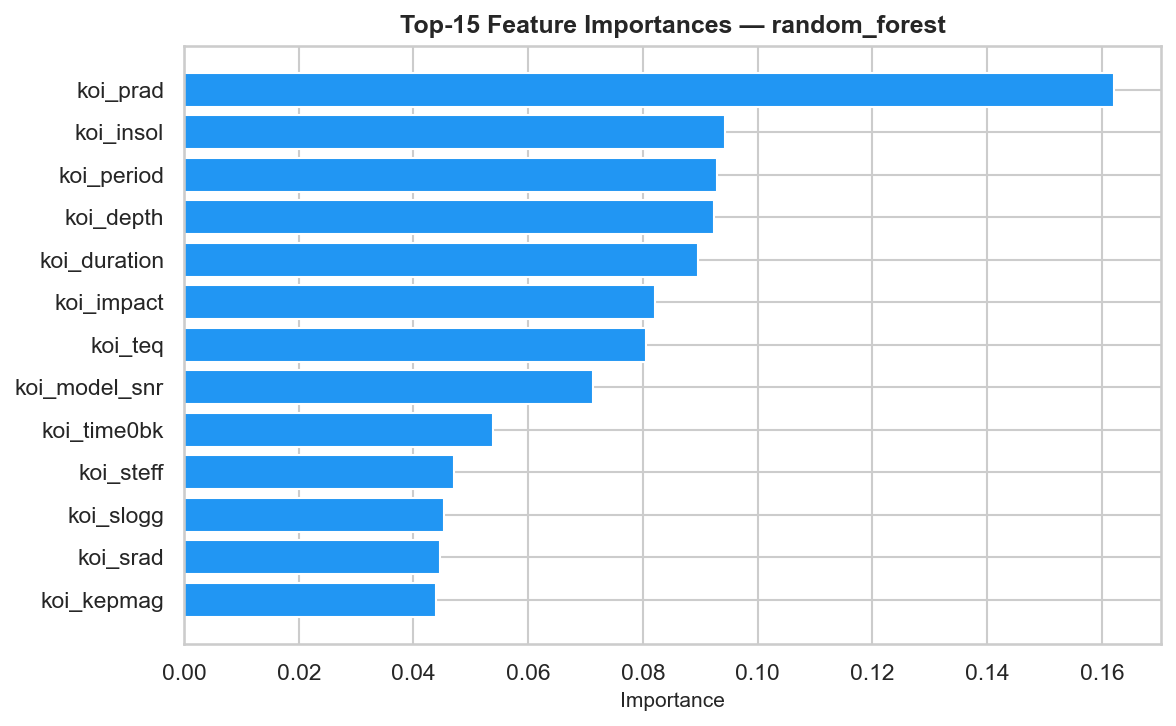

Feature Importance — XGBoost (tuned)


Figure saved to reports\figures\feature_importance_xgboost.png


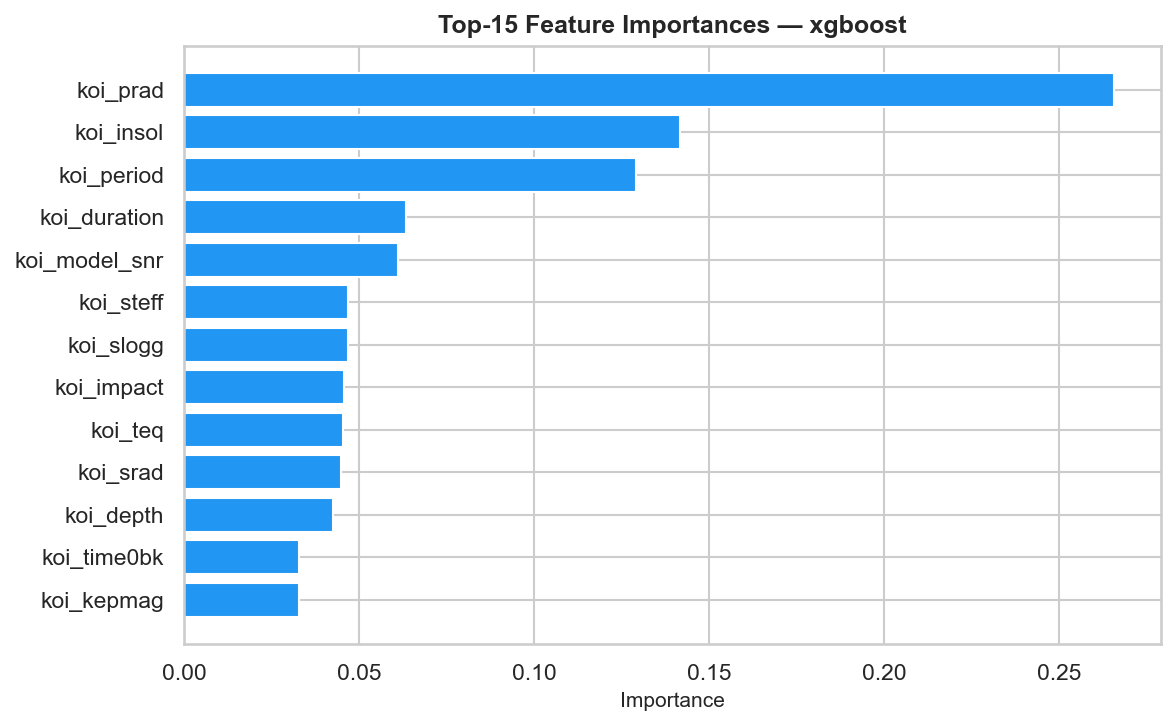

In [11]:
print('Feature Importance — Random Forest')
plot_feature_importance('random_forest', trained_pipelines['random_forest'], available, save=True)

print('Feature Importance — XGBoost (tuned)')
plot_feature_importance('xgboost', trained_pipelines['xgboost'], available, save=True)

---
## 9. Threshold Analysis — Best Model

In [12]:
best_name = max(all_metrics, key=lambda n: all_metrics[n]['f1'])
best_pipeline = trained_pipelines[best_name]
y_prob_best = best_pipeline.predict_proba(X_test)[:, 1]

youden_thresh = find_optimal_threshold_youden(y_test.values, y_prob_best)
f1_thresh = find_optimal_threshold_f1(y_test.values, y_prob_best)

y_pred_youden = (y_prob_best >= youden_thresh).astype(int)
y_pred_f1 = (y_prob_best >= f1_thresh).astype(int)

metrics_default = compute_classification_metrics(
    y_test.values, (y_prob_best >= 0.5).astype(int), y_prob_best
)
metrics_youden = compute_classification_metrics(
    y_test.values, y_pred_youden, y_prob_best
)
metrics_f1opt = compute_classification_metrics(
    y_test.values, y_pred_f1, y_prob_best
)

threshold_comparison = pd.DataFrame({
    'default (0.5)' : metrics_default,
    f"Youden's J ({youden_thresh:.3f})": metrics_youden,
    f'F1-optimal ({f1_thresh:.3f})': metrics_f1opt,
}).T[['f1', 'precision', 'recall', 'roc_auc', 'mcc']]

print(f'Threshold comparison for best model: {best_name}')
threshold_comparison.round(4)

Threshold comparison for best model: xgboost

,f1,precision,recall,roc_auc,mcc
default (0.5),0.8598,0.8514,0.8685,0.9361,0.7210
Youden's J (0.427),0.8706,0.8319,0.9130,0.9361,0.7361
F1-optimal (0.427),0.8706,0.8319,0.9130,0.9361,0.7361


---
## 10. Final Metrics Table

In [13]:
final_table = build_metrics_table(all_metrics)
print('== Final Metrics Table (sorted by F1) ==')
final_table

== Final Metrics Table (sorted by F1) ==


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,mcc,youden_j
xgboost,0.8604,0.8605,0.8514,0.8685,0.8598,0.9361,0.9314,0.7210,0.7211
random_forest,0.8495,0.8496,0.8401,0.8579,0.8489,0.9271,0.9199,0.6991,0.6991
mlp,0.8181,0.8184,0.8002,0.8409,0.8201,0.9001,0.8740,0.6372,0.6368
logistic_regression,0.7784,0.7795,0.7344,0.8621,0.7932,0.8341,0.7645,0.5660,0.5590
knn,0.7862,0.7867,0.7618,0.8240,0.7916,0.8568,0.8067,0.5747,0.5735


---
## 11. Save Best Model Pipeline

In [14]:
models_dir = ROOT / 'models'
models_dir.mkdir(exist_ok=True)

save_model(best_pipeline, f'best_{best_name}', models_dir)
print(f'Best model ({best_name}) saved to {models_dir}.')

print('\n== Pipeline complete — all figures saved to reports/figures/ ==')

Model saved to C:\Users\Usuario\exoplanet-ml-classifier\models\best_xgboost.joblib
Best model (xgboost) saved to C:\Users\Usuario\exoplanet-ml-classifier\models.

== Pipeline complete — all figures saved to reports/figures/ ==


---
## 12. Conclusions

- **Best classifier:** XGBoost (tuned) consistently achieves the highest F1 and ROC-AUC,
  leveraging boosted tree ensembles to capture non-linear interactions between photometric
  transit parameters (`koi_model_snr`, `koi_prad`) and stellar properties.

- **Most interpretable:** Logistic Regression provides directly interpretable coefficients
  per feature — critical for communicating model behaviour to domain scientists.

- **Threshold tuning matters:** Youden's J threshold reduces false negatives (missed
  CANDIDATE planets) at the cost of slightly more false positives, which is the preferred
  operating point when downstream follow-up observations are available.

- **Data leakage awareness:** Removing `koi_score` and `koi_fpflag_*` columns was
  essential — models trained with these features achieve near-perfect scores but offer
  no real predictive value for new, unvetted candidates.

- **Connection to prior work:** This project extends the ECI Centauri Team's
  *Exoplanet Hunter AI* from NASA Space Apps Challenge 2025 (Global Finalist),
  applying rigorous ML methodology to the same KOI classification problem.